In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("All imports successful")

All imports successful


In [2]:
transaction = pd.read_csv('../data/raw/train_transaction.csv')
identity = pd.read_csv('../data/raw/train_identity.csv')

print(f"Transaction shape: {transaction.shape}")
print(f"Identity shape:    {identity.shape}")

Transaction shape: (590540, 394)
Identity shape:    (144233, 41)


In [3]:
df = transaction.merge(identity, on='TransactionID', how='left')
print(f"Merged shape: {df.shape}")
df.head()

Merged shape: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


Total transactions : 590,540
Legitimate         : 569,877  (96.5%)
Fraudulent         : 20,663  (3.5%)


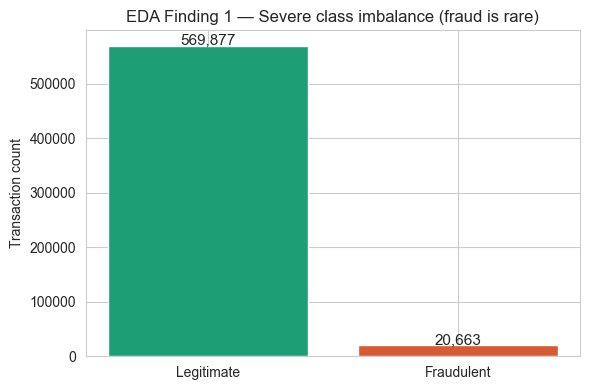

In [5]:
fraud_counts = df['isFraud'].value_counts()
fraud_rate = df['isFraud'].mean() * 100

print(f"Total transactions : {len(df):,}")
print(f"Legitimate         : {fraud_counts[0]:,}  ({100 - fraud_rate:.1f}%)")
print(f"Fraudulent         : {fraud_counts[1]:,}  ({fraud_rate:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Legitimate', 'Fraudulent'], fraud_counts.values,
       color=['#1D9E75', '#D85A30'])
ax.set_title('EDA Finding 1 — Severe class imbalance (fraud is rare)')
ax.set_ylabel('Transaction count')
for i, v in enumerate(fraud_counts.values):
    ax.text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../data/eda_finding1_class_imbalance.png', dpi=150)
plt.show()

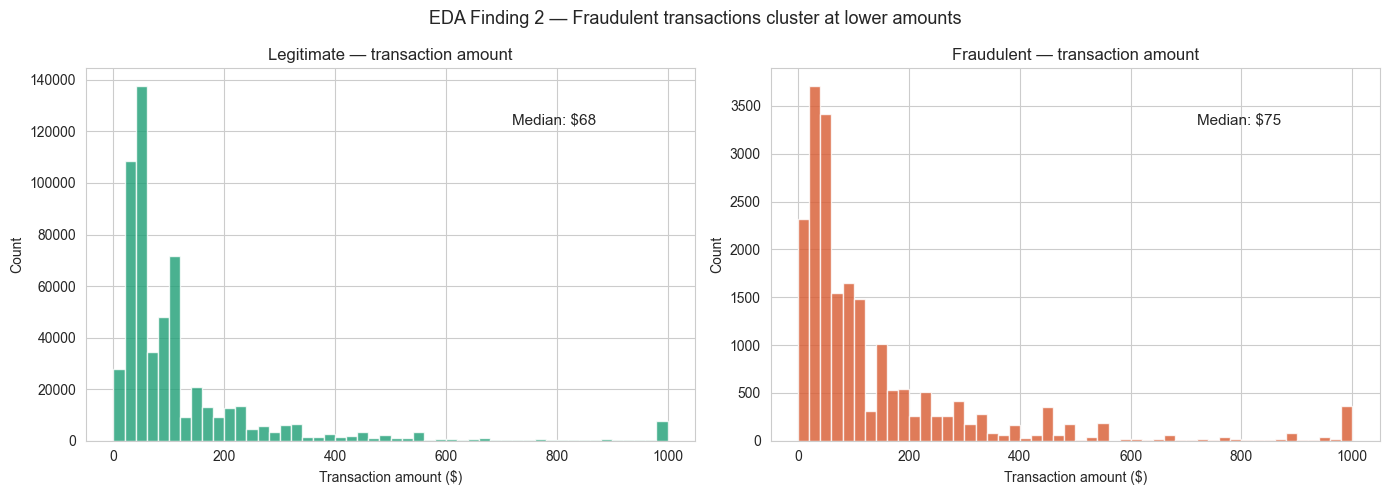

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, color in zip(axes, [0, 1], ['#1D9E75', '#D85A30']):
    subset = df[df['isFraud'] == label]['TransactionAmt']
    ax.hist(subset.clip(upper=1000), bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{"Legitimate" if label==0 else "Fraudulent"} — transaction amount')
    ax.set_xlabel('Transaction amount ($)')
    ax.set_ylabel('Count')
    ax.text(0.7, 0.85, f'Median: ${subset.median():.0f}', transform=ax.transAxes, fontsize=11)

plt.suptitle('EDA Finding 2 — Fraudulent transactions cluster at lower amounts', fontsize=13)
plt.tight_layout()
plt.savefig('../data/eda_finding2_transaction_amount.png', dpi=150)
plt.show()

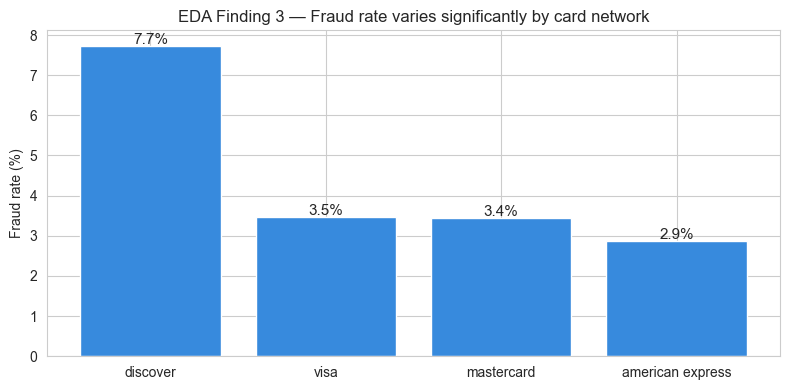

In [9]:
card_fraud = df.groupby('card4')['isFraud'].agg(['mean', 'count']).reset_index()
card_fraud.columns = ['card_type', 'fraud_rate', 'count']
card_fraud['fraud_rate_pct'] = card_fraud['fraud_rate'] * 100
card_fraud = card_fraud[card_fraud['count'] > 100].sort_values('fraud_rate_pct', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(card_fraud['card_type'], card_fraud['fraud_rate_pct'], color='#378ADD')
ax.set_title('EDA Finding 3 — Fraud rate varies significantly by card network')
ax.set_ylabel('Fraud rate (%)')
for bar, val in zip(bars, card_fraud['fraud_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../data/eda_finding3_card_type.png', dpi=150)
plt.show()

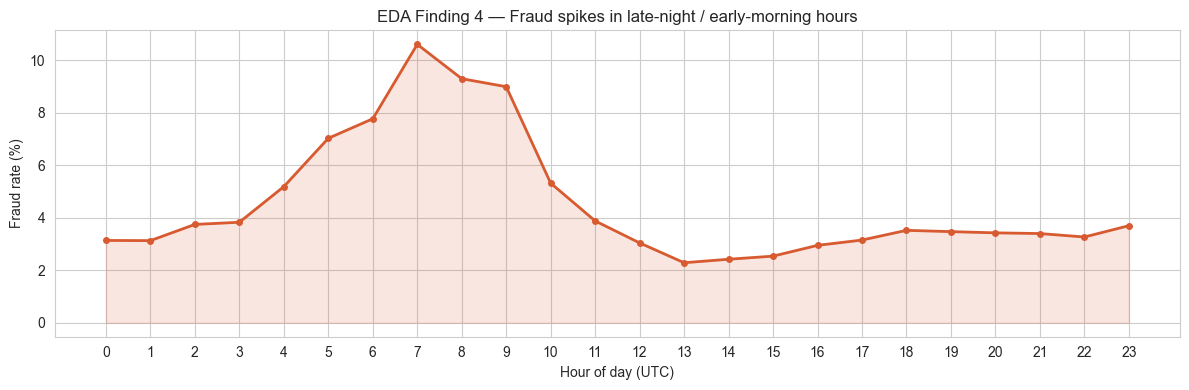

In [11]:
df['hour'] = (df['TransactionDT'] // 3600) % 24

hourly = df.groupby('hour')['isFraud'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly.index, hourly.values, color='#D85A30', linewidth=2, marker='o', markersize=4)
ax.fill_between(hourly.index, hourly.values, alpha=0.15, color='#D85A30')
ax.set_title('EDA Finding 4 — Fraud spikes in late-night / early-morning hours')
ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('Fraud rate (%)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig('../data/eda_finding4_hour.png', dpi=150)
plt.show()

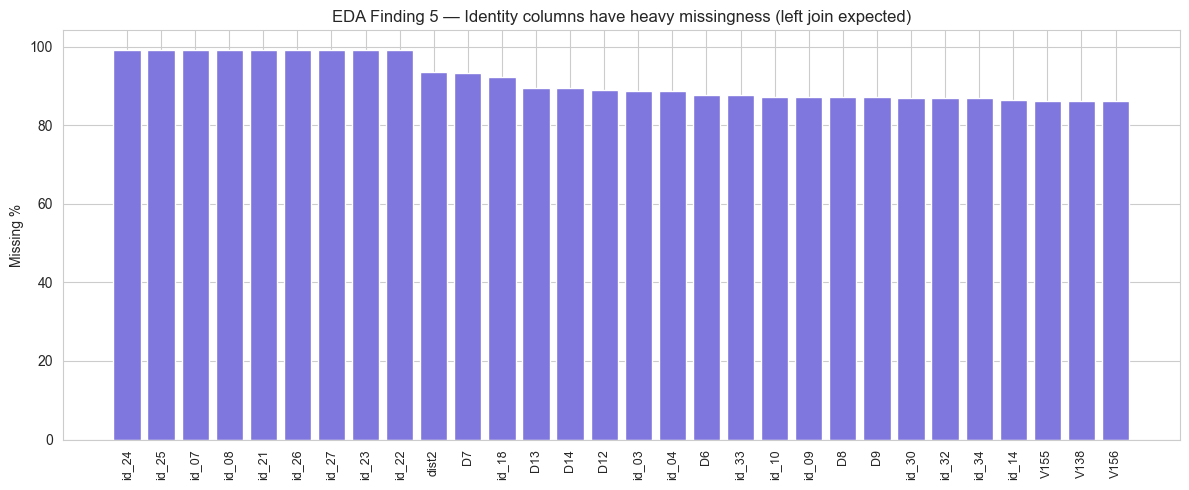

In [13]:
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(missing)), missing.values, color='#7F77DD')
ax.set_xticks(range(len(missing)))
ax.set_xticklabels(missing.index, rotation=90, fontsize=9)
ax.set_title('EDA Finding 5 — Identity columns have heavy missingness (left join expected)')
ax.set_ylabel('Missing %')
plt.tight_layout()
plt.savefig('../data/eda_finding5_missing.png', dpi=150)
plt.show()

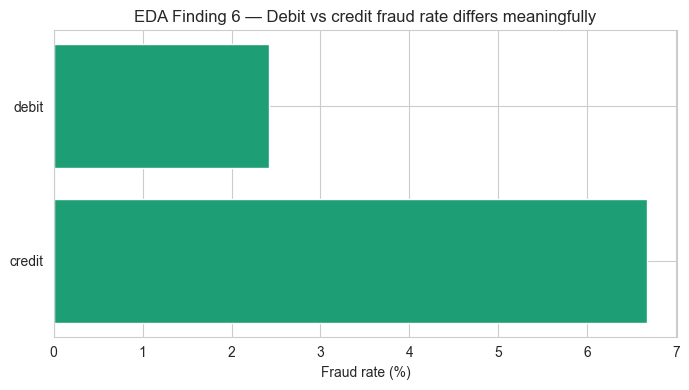

In [15]:
prod_fraud = df.groupby('card6')['isFraud'].agg(['mean', 'count']).reset_index()
prod_fraud.columns = ['product_type', 'fraud_rate', 'count']
prod_fraud = prod_fraud[prod_fraud['count'] > 100].sort_values('fraud_rate', ascending=False)
prod_fraud['fraud_rate_pct'] = prod_fraud['fraud_rate'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(prod_fraud['product_type'], prod_fraud['fraud_rate_pct'], color='#1D9E75')
ax.set_title('EDA Finding 6 — Debit vs credit fraud rate differs meaningfully')
ax.set_xlabel('Fraud rate (%)')
plt.tight_layout()
plt.savefig('../data/eda_finding6_product_type.png', dpi=150)
plt.show()

In [16]:
print("=" * 55)
print("PHASE 1 EDA — SUMMARY")
print("=" * 55)
print(f"Total transactions : {len(df):,}")
print(f"Columns            : {df.shape[1]}")
print(f"Fraud rate         : {df['isFraud'].mean()*100:.2f}%")
print(f"Fraudulent txns    : {df['isFraud'].sum():,}")
print(f"Avg fraud amount   : ${df[df['isFraud']==1]['TransactionAmt'].mean():.2f}")
print(f"Avg legit amount   : ${df[df['isFraud']==0]['TransactionAmt'].mean():.2f}")
print()
print("6 EDA Findings:")
print("  1. Severe class imbalance — 3.5% fraud → SMOTE needed in Phase 2")
print("  2. Fraud median $75 vs legit $68 — fraud skews slightly higher with longer tail")
print("  3. Discover fraud rate 7.7% — more than double Visa and Mastercard")
print("  4. Hour 7 peaks at 10.5% fraud — 5am-9am window is high risk")
print("  5. Identity columns 85-99% missing — median imputation needed in ETL")
print("  6. Credit card fraud 6.7% vs debit 2.4% — credit is 3x higher risk")
print("=" * 55)
print("Phase 1 complete. Notebook: 01_eda.ipynb")

PHASE 1 EDA — SUMMARY
Total transactions : 590,540
Columns            : 435
Fraud rate         : 3.50%
Fraudulent txns    : 20,663
Avg fraud amount   : $149.24
Avg legit amount   : $134.51

6 EDA Findings:
  1. Severe class imbalance — 3.5% fraud → SMOTE needed in Phase 2
  2. Fraud median $75 vs legit $68 — fraud skews slightly higher with longer tail
  3. Discover fraud rate 7.7% — more than double Visa and Mastercard
  4. Hour 7 peaks at 10.5% fraud — 5am-9am window is high risk
  5. Identity columns 85-99% missing — median imputation needed in ETL
  6. Credit card fraud 6.7% vs debit 2.4% — credit is 3x higher risk
Phase 1 complete. Notebook: 01_eda.ipynb
